In [2]:
# ================================================
# IPL Business Intelligence & Forecasting Project
# Notebook 3: Player Performance Analysis
# Author: Bhoomi Thakur
# ================================================

import pandas as pd
import matplotlib.pyplot as plt

# Load clean data
ipl = pd.read_csv('E:\\ipl_dataset1\\ipl_clean.csv', 
                   low_memory=False)

# Fix season
ipl['season'] = ipl['season'].astype(str).str[:4].astype(int)
ipl = ipl[ipl['season'] != 2026]

print("Shape:", ipl.shape)
print("Columns:", ipl.columns.tolist())

Shape: (278205, 44)
Columns: ['match_id', 'date', 'match_type', 'event_name', 'innings', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'runs_batter', 'balls_faced', 'bowler', 'runs_extras', 'runs_total', 'runs_bowler', 'extra_type', 'non_striker', 'wicket_kind', 'player_out', 'fielders', 'runs_target', 'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'month', 'year', 'season', 'superover_winner', 'result_type', 'method', 'overs', 'stage', 'match_number', 'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'next_batter', 'phase']


In [3]:
# Drop all unnamed columns
unnamed_cols = [col for col in ipl.columns if 'Unnamed' in col]
print("Dropping:", unnamed_cols)
ipl.drop(columns=unnamed_cols, inplace=True)

print("Clean shape:", ipl.shape)

Dropping: ['Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0']
Clean shape: (278205, 44)


In [4]:
ipl.to_csv('E:\\ipl_dataset1\\ipl_clean.csv', index=False)
print(" Saved ")

 Saved 


In [5]:
ipl = pd.read_csv('E:\\ipl_dataset1\\ipl_clean.csv',
                   low_memory=False)
print("Final shape:", ipl.shape)
print("Any unnamed:", [c for c in ipl.columns if 'Unnamed' in c])

Final shape: (278205, 44)
Any unnamed: []


In [6]:
# Total runs per batsman
top_batsmen = ipl.groupby('batter')['runs_batter']\
               .sum().reset_index(name='total_runs')\
               .sort_values('total_runs', ascending=False)\
               .head(10)

print(top_batsmen)

             batter  total_runs
658         V Kohli        8671
500       RG Sharma        7048
535        S Dhawan        6769
151       DA Warner        6567
569        SK Raina        5536
389        MS Dhoni        5439
297        KL Rahul        5235
31   AB de Villiers        5181
51        AM Rahane        5032
128        CH Gayle        4997


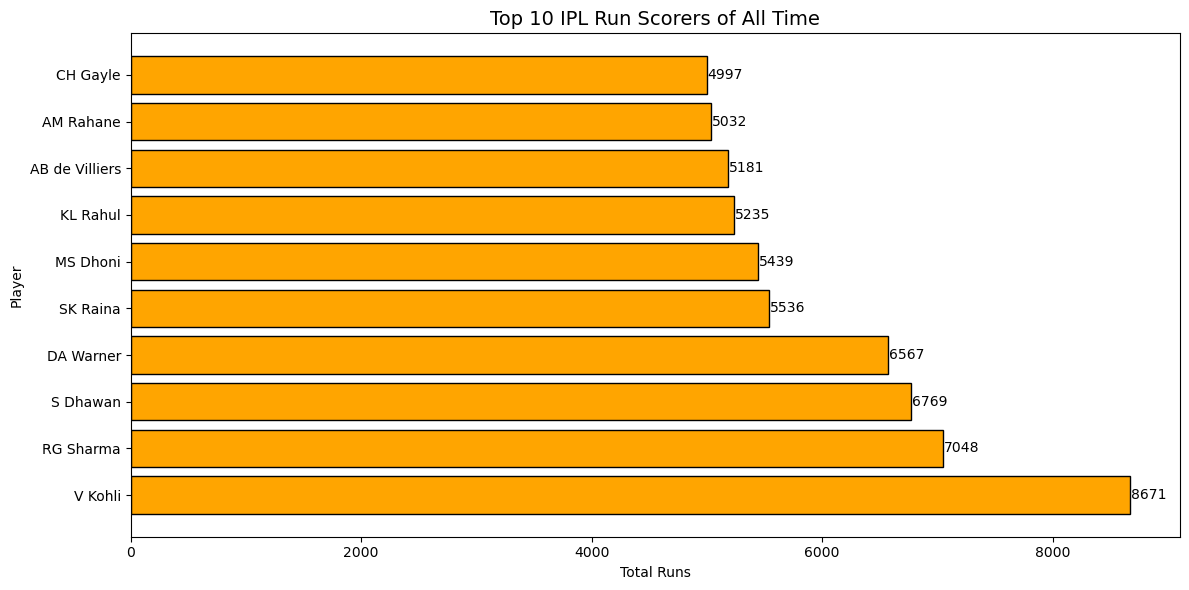

In [7]:
plt.figure(figsize=(12,6))
plt.barh(top_batsmen['batter'], top_batsmen['total_runs'],
         color='orange', edgecolor='black')

# Add value labels
for index, value in enumerate(top_batsmen['total_runs']):
    plt.text(value + 10, index, str(value), va='center')

plt.title('Top 10 IPL Run Scorers of All Time', fontsize=14)
plt.xlabel('Total Runs')
plt.ylabel('Player')
plt.tight_layout()
plt.savefig('E:\\ipl_dataset1\\visuals\\top_batsmen.png', dpi=150)
plt.show()

In [8]:
# Only count actual wickets (not run outs - those are fielding)
wickets = ipl[~ipl['wicket_kind'].isin(
    ['none', 'run out', 'obstructing the field']
)]

top_bowlers = wickets.groupby('bowler')['wicket_kind']\
               .count().reset_index(name='total_wickets')\
               .sort_values('total_wickets', ascending=False)\
               .head(10)

print(top_bowlers)

         bowler  total_wickets
459   YS Chahal            221
62      B Kumar            198
389   SP Narine            192
305   PP Chawla            192
314    R Ashwin            188
173   JJ Bumrah            186
104    DJ Bravo            183
7      A Mishra            174
329   RA Jadeja            170
382  SL Malinga            170


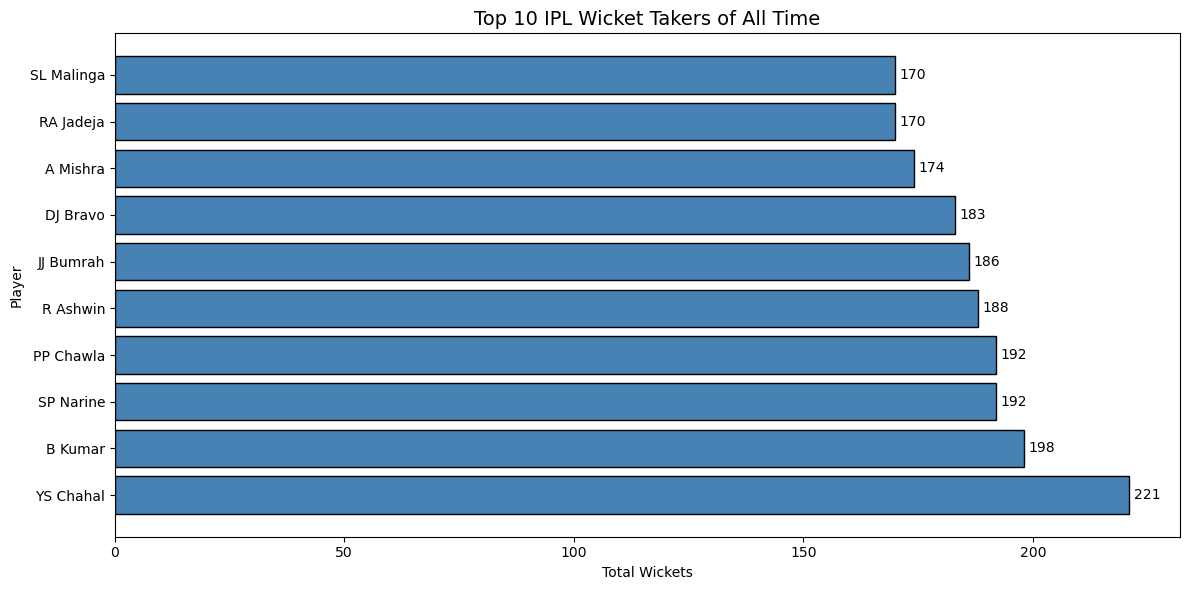

In [9]:
plt.figure(figsize=(12,6))
plt.barh(top_bowlers['bowler'], top_bowlers['total_wickets'],
         color='steelblue', edgecolor='black')

for index, value in enumerate(top_bowlers['total_wickets']):
    plt.text(value + 1, index, str(value), va='center')

plt.title('Top 10 IPL Wicket Takers of All Time', fontsize=14)
plt.xlabel('Total Wickets')
plt.ylabel('Player')
plt.tight_layout()
plt.savefig('E:\\ipl_dataset1\\visuals\\top_bowlers.png', dpi=150)
plt.show()

In [10]:
# Strike rate = runs scored / balls faced * 100
# Min 500 balls to filter out players with few matches

strike_rate = ipl.groupby('batter').agg(
    total_runs=('runs_batter', 'sum'),
    total_balls=('balls_faced', 'sum')
).reset_index()

# Filter minimum 500 balls
strike_rate = strike_rate[strike_rate['total_balls'] >= 500]

# Calculate strike rate
strike_rate['strike_rate'] = (
    strike_rate['total_runs'] / 
    strike_rate['total_balls'] * 100
).round(2)

# Top 10
top_sr = strike_rate.sort_values(
    'strike_rate', ascending=False).head(10)

print(top_sr)

              batter  total_runs  total_balls  strike_rate
449          PD Salt        1056          601       175.71
40        AD Russell        2655         1525       174.10
643          TM Head        1146          674       170.03
213        H Klaasen        1480          872       169.72
412         N Pooran        2293         1359       168.73
585        SP Narine        1780         1069       166.51
71   Abhishek Sharma        1816         1114       163.02
334   LS Livingstone        1051          662       158.76
265        JM Sharma         991          631       157.05
661         V Sehwag        2728         1755       155.44


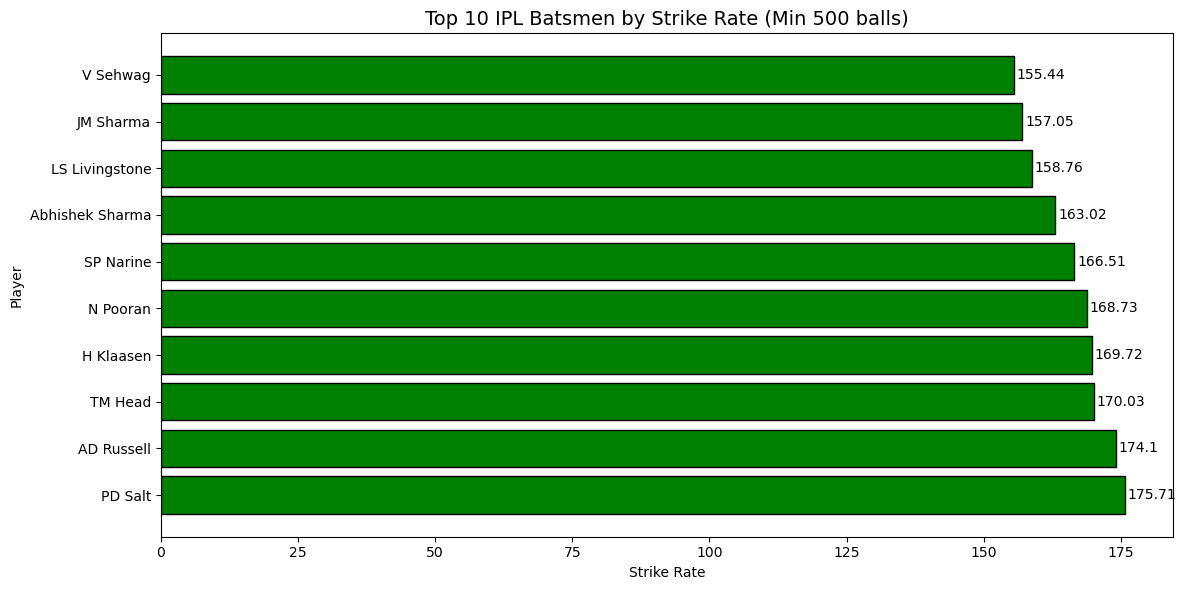

In [11]:
plt.figure(figsize=(12,6))
plt.barh(top_sr['batter'], top_sr['strike_rate'],
         color='green', edgecolor='black')

for index, value in enumerate(top_sr['strike_rate']):
    plt.text(value + 0.5, index, str(value), va='center')

plt.title('Top 10 IPL Batsmen by Strike Rate (Min 500 balls)', 
          fontsize=14)
plt.xlabel('Strike Rate')
plt.ylabel('Player')
plt.tight_layout()
plt.savefig('E:\\ipl_dataset1\\visuals\\strike_rate.png', dpi=150)
plt.show()

In [14]:
# Economy = runs conceded per over (6 balls)
economy = ipl.groupby('bowler').agg(
    total_runs=('runs_bowler', 'sum'),
    total_balls=('runs_bowler', 'count')  # count rows = balls bowled
).reset_index()

# Filter minimum 300 balls bowled
economy = economy[economy['total_balls'] >= 300]

# Calculate economy rate
economy['economy'] = (
    economy['total_runs'] / 
    economy['total_balls'] * 6
).round(2)

# Top 10 most economical
top_economy = economy.sort_values(
    'economy', ascending=True).head(10)

print(top_economy)

               bowler  total_runs  total_balls  economy
7            A Kumble        1058          983     6.46
271    M Muralitharan        1706         1581     6.47
151        GD McGrath         357          329     6.51
391  RE van der Merwe         498          455     6.57
141          DW Steyn        2523         2282     6.63
460         SP Narine        4933         4421     6.69
188           J Yadav         445          398     6.71
132        DL Vettori         879          785     6.72
182           J Botha         800          709     6.77
452        SL Malinga        3366         2974     6.79


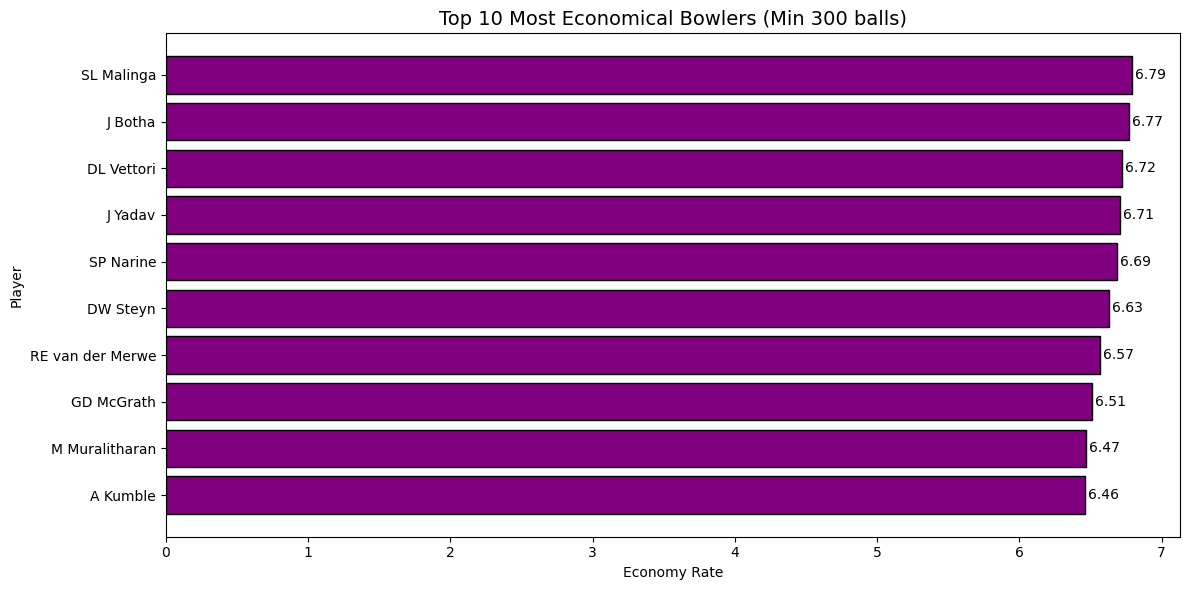

In [15]:
plt.figure(figsize=(12,6))
plt.barh(top_economy['bowler'], top_economy['economy'],
         color='purple', edgecolor='black')

for index, value in enumerate(top_economy['economy']):
    plt.text(value + 0.02, index, str(value), va='center')

plt.title('Top 10 Most Economical Bowlers (Min 300 balls)', 
          fontsize=14)
plt.xlabel('Economy Rate')
plt.ylabel('Player')
plt.tight_layout()
plt.savefig('E:\\ipl_dataset1\\visuals\\economy_rate.png', dpi=150)
plt.show()

In [16]:
# Who scores most in death overs?
death_batting = ipl[ipl['phase'] == 'Death'].groupby('batter').agg(
    death_runs=('runs_batter', 'sum'),
    death_balls=('runs_batter', 'count')
).reset_index()

# Minimum 100 balls in death overs
death_batting = death_batting[death_batting['death_balls'] >= 100]

# Calculate death strike rate
death_batting['death_sr'] = (
    death_batting['death_runs'] /
    death_batting['death_balls'] * 100
).round(2)

# Top 10
top_death = death_batting.sort_values(
    'death_sr', ascending=False).head(10)

print(top_death)

             batter  death_runs  death_balls  death_sr
548        T Stubbs         370          154    240.26
27   AB de Villiers        1421          635    223.78
372      Naman Dhir         222          106    209.43
295  LS Livingstone         241          118    204.24
185       H Klaasen         434          217    200.00
531  Shashank Singh         360          181    198.90
450         RR Pant         696          356    195.51
110        CH Gayle         404          209    193.30
569         V Kohli        1121          586    191.30
225       JH Kallis         303          159    190.57


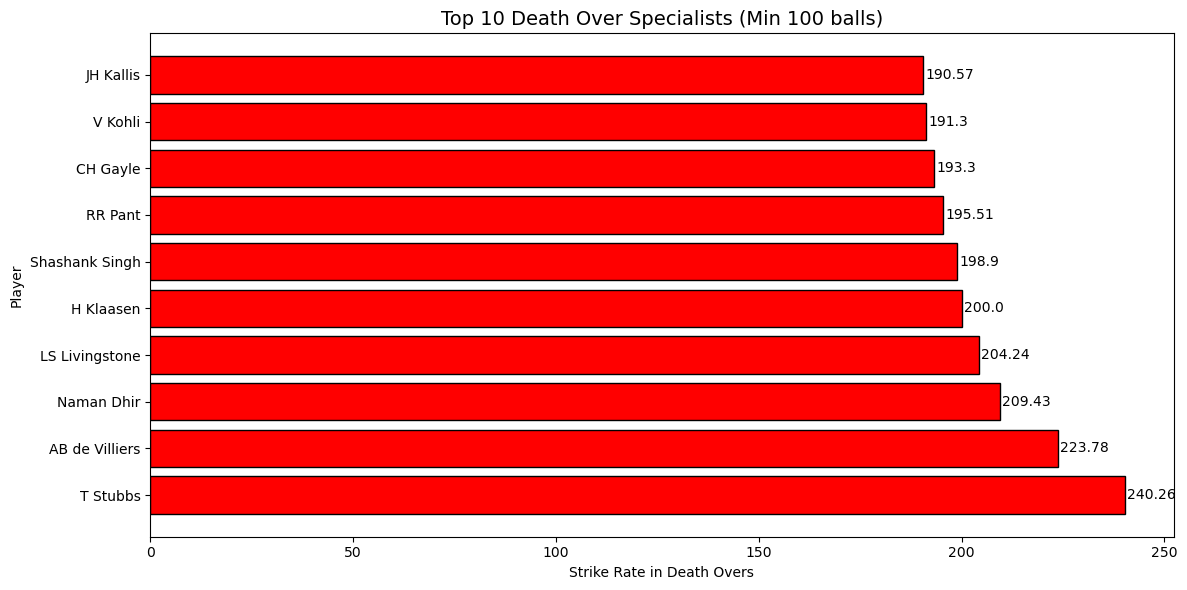

In [17]:
plt.figure(figsize=(12,6))
plt.barh(top_death['batter'], top_death['death_sr'],
         color='red', edgecolor='black')

for index, value in enumerate(top_death['death_sr']):
    plt.text(value + 0.5, index, str(value), va='center')

plt.title('Top 10 Death Over Specialists (Min 100 balls)', 
          fontsize=14)
plt.xlabel('Strike Rate in Death Overs')
plt.ylabel('Player')
plt.tight_layout()
plt.savefig('E:\\ipl_dataset1\\visuals\\death_specialists.png', 
            dpi=150)
plt.show()

In [3]:
import sqlite3

# Create database from your clean CSV
conn = sqlite3.connect('E:\\ipl_dataset1\\ipl.db')
ipl.to_sql('ipl', conn, if_exists='replace', index=False)
print("Database created!")
conn.close()

Database created!
